In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Reproducibilidad: fijamos semilla global
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("hola")

hola


## Clasificación de canciones K-pop usando KNN
---

### Resumen del problema

La disquera **UAI Music Group** necesita clasificar automáticamente si una canción de su catálogo pertenece al género **K-pop** o no, con el fin de orientar su expansión hacia el mercado asiático. El proceso manual (contratar a un experto musical) es caro y lento, lo cual erosiona el *time-to-market*. La solución propuesta es entrenar un modelo de **K-Nearest Neighbors (KNN)** sobre un conjunto de canciones ya etiquetadas y evaluarlo con **10-fold cross validation**.


1. Importamos los datos: de las 21 columnas originales, se extraen únicamente las **6 variables solicitadas en el enunciado**

In [2]:
# Cargamos el csv
df_raw = pd.read_csv('dataset_tarea.csv')
print(f"Dimensiones originales: {df_raw.shape}")
print(f"Columnas disponibles ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())


Dimensiones originales: (2000, 21)
Columnas disponibles (21):
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [3]:
# Selección de las 6 variables del enunciado
cols_features = ['popularity', 'danceability', 'speechiness', 'acousticness', 'loudness']
col_target = 'track_genre'

df = df_raw[cols_features + [col_target]].copy()
print(f"Dimensiones tras la selección: {df.shape}")
print(df.head())
print(df.tail())

Dimensiones tras la selección: (2000, 6)
   popularity  danceability  speechiness  acousticness  loudness  track_genre
0          87         0.588       0.0329        0.0678    -9.461            0
1          83         0.705       0.0385        0.0102    -6.156            0
2          86         0.575       0.0300        0.0484    -5.509            0
3          93         0.612       0.0336        0.0495    -2.810            0
4          83         0.551       0.0542        0.1860    -6.099            0
      popularity  danceability  speechiness  acousticness  loudness  \
1995          44         0.622       0.0437        0.1610    -7.730   
1996          42         0.806       0.0487        0.2890    -4.674   
1997          61         0.703       0.0682        0.0296    -3.479   
1998          43         0.639       0.0430        0.1380    -7.675   
1999          43         0.498       0.0327        0.8640   -12.622   

      track_genre  
1995            1  
1996            1  
1997

## 2. Limpieza de Datos

### 2.1 ¿Por qué limpiar?

Vamos a verificar la existencia de datos nulos, inconsistentes u outliers, para así poder tomar una decisión respecto a una eliminación, imputación o simplemente dejarlos.


In [4]:
# Inspección de nulos
print("=== Valores nulos por columna ===")
print(df.isnull().sum())
print(f"\nTotal filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")


=== Valores nulos por columna ===
popularity      0
danceability    0
speechiness     0
acousticness    0
loudness        0
track_genre     0
dtype: int64

Total filas con al menos un nulo: 0


In [5]:
# Inspección de tipos y resumen estadístico
print("=== Tipos de dato ===")
print(df.dtypes)
print("\n=== Resumen estadístico ===")
df.describe()

=== Tipos de dato ===
popularity        int64
danceability    float64
speechiness     float64
acousticness    float64
loudness        float64
track_genre       int64
dtype: object

=== Resumen estadístico ===


,popularity,danceability,speechiness,acousticness,loudness,track_genre
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,45.419500,0.591112,0.071547,0.207565,-6.331132,0.500000
std,27.574167,0.146103,0.068230,0.257946,2.651082,0.500125
min,0.000000,0.112000,0.023000,0.000003,-18.108000,0.000000
25%,42.000000,0.497750,0.034600,0.011575,-7.801250,0.000000
50%,51.500000,0.598000,0.047600,0.074300,-5.900000,0.500000
75%,67.000000,0.697000,0.079050,0.331000,-4.486250,1.000000
max,93.000000,0.935000,0.889000,0.983000,-0.173000,1.000000


In [6]:
print(f"\ntrack_genre — valores únicos: {sorted(df['track_genre'].unique())}")
print(f"track_genre — distribución:\n{df['track_genre'].value_counts()}")


track_genre — valores únicos: [np.int64(0), np.int64(1)]
track_genre — distribución:
track_genre
0    1000
1    1000
Name: count, dtype: int64


**Hallazgos:**

- **No hay valores nulos** en ninguna de las 6 columnas seleccionadas.
- Todos los rangos son **consistentes con lo declarado** en el enunciado: `popularity` está en [0, 100], las tres variables 0–1 están dentro de su rango, y `loudness` tiene valores negativos, lo que nos indica que probablemente vamos a tener que estandarizar las variables para que el modelo funcione correctamente.
- La etiqueta `track_genre` está **balanceada**: 1000 K-pop y 1000 No-K-pop. Esto es deseable porque evita que un clasificador trivial ("predecir siempre la clase mayoritaria") obtenga buen accuracy sin aprender nada.

**Conclusión obtenida:** *no fue necesario eliminar ni imputar filas por nulos o inconsistencias*. El dataset llega limpio a nivel de integridad básica.

### 2.3 Detección de outliers con LOF (Local Outlier Factor)

Aunque no hay nulos, los valores extremos aún pueden afectar a KNN. Aplicamos **LOF**, que es el algoritmo más apropiado para este caso porque:

- Es un método de **distancia local**: compara la densidad alrededor de cada punto con la densidad de sus vecinos. Un punto en una región de baja densidad relativa recibe un *score* alto y se marca como atípico.


Usamos `n_neighbors=20` (valor estándar de la literatura) y que deja que el algoritmo determine internamente el umbral.


In [7]:
# LOF sobre las 5 variables predictoras (sin la etiqueta)
X_full = df[cols_features].values

lof = LocalOutlierFactor(n_neighbors=20)
lof_flags = lof.fit_predict(X_full)  # +1 = inlier, -1 = outlier

n_outliers = (lof_flags == -1).sum()
print(f"Outliers detectados por LOF: {n_outliers} de {len(X_full)} "
      f"({100*n_outliers/len(X_full):.2f}%)")


Outliers detectados por LOF: 119 de 2000 (5.95%)


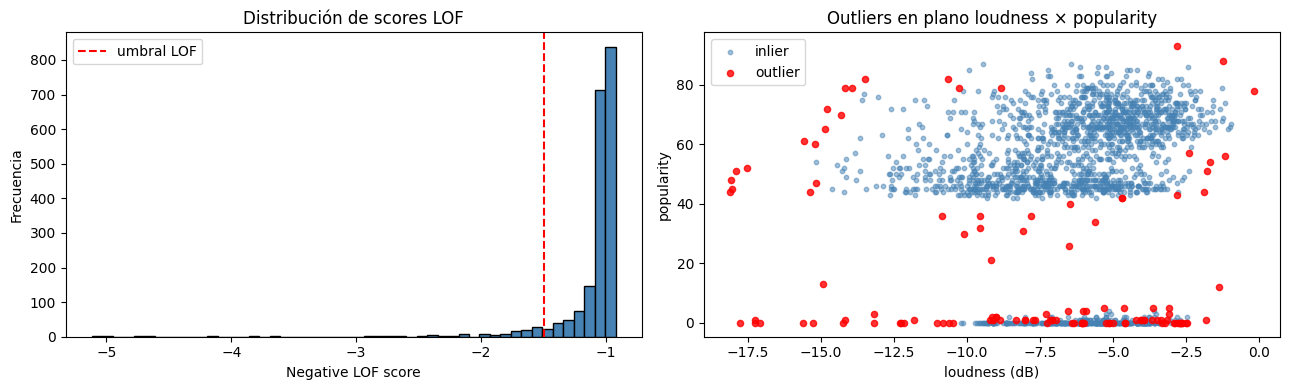

In [8]:
# Visualización: scores LOF (más negativo = más anómalo)
lof_scores = lof.negative_outlier_factor_

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lof_scores, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(np.percentile(lof_scores, 100*n_outliers/len(X_full)),
                color='red', linestyle='--', label='umbral LOF')
axes[0].set_xlabel('Negative LOF score')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de scores LOF')
axes[0].legend()

# Scatter loudness vs popularity coloreando outliers
mask_out = lof_flags == -1
axes[1].scatter(df.loc[~mask_out, 'loudness'], df.loc[~mask_out, 'popularity'],
                c='steelblue', s=10, alpha=0.5, label='inlier')
axes[1].scatter(df.loc[mask_out, 'loudness'], df.loc[mask_out, 'popularity'],
                c='red', s=20, alpha=0.8, label='outlier')
axes[1].set_xlabel('loudness (dB)')
axes[1].set_ylabel('popularity')
axes[1].set_title('Outliers en plano loudness × popularity')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.4 Decisión sobre los outliers

**Qué se hace con ellos:** los **eliminamos** del dataset antes de entrenar KNN.

**Justificación:**

1. **KNN es paramétrico cero y muy local**: con K=1, un único outlier puede convertirse en el vecino más cercano de varios puntos de test y arrastrar predicciones erróneas. El problema se atenúa pero no desaparece con K mayor.
2. La cantidad detectada (≈6%) es **pequeña** respecto al total, así que removerla no compromete el tamaño efectivo de la muestra ni cambia significativamente la distribución de clases (revisar el `value_counts` anterior — el balance se mantiene aproximado).
3. **Alternativas descartadas:** imputar no aplica (no son nulos, son valores válidos pero extremos).

Construimos así el dataset limpio `df_clean` que se usará desde aquí en adelante.


In [9]:
# Dataset limpio sin outliers
df_clean = df[~mask_out].reset_index(drop=True)
print(f"Filas antes:   {len(df)}")
print(f"Filas después: {len(df_clean)}")
print(f"Removidas:     {len(df) - len(df_clean)}")
print(f"\nBalance de clases tras limpieza:\n{df_clean[col_target].value_counts()}")

# Matrices que usaremos en todo el resto del notebook
X = df_clean[cols_features].values
y = df_clean[col_target].values
print(f"\nForma final: X={X.shape}, y={y.shape}")


Filas antes:   2000
Filas después: 1881
Removidas:     119

Balance de clases tras limpieza:
track_genre
1    963
0    918
Name: count, dtype: int64

Forma final: X=(1881, 5), y=(1881,)


## 3. Evaluación de KNN con K=1, 10-fold CV y `min_max()`

Si los atributos están en **escalas muy distintas**, los de mayor magnitud dominan la suma. Mirando los rangos de nuestras variables:

- `popularity` varía en órdenes de **decenas**
- `danceability`, `speechiness`, `acousticness` varían en órdenes de **décimas**
- `loudness` (dB) varía en un rango de **decenas negativas**

Sin normalizar, `popularity` y `loudness` aplastarían por completo la contribución de las variables 0–1 al cálculo de distancia, aunque éstas puedan ser muy discriminantes para distinguir K-pop. Normalizar pone a todas las variables en igualdad de condiciones.

### 3.2 ¿Por qué normalizar *dentro* de cada fold y no antes?

Esta es la trampa clásica de **data leakage**: si calculamos `min` y `max` sobre **todo** el dataset y luego hacemos CV, estamos filtrando información del fold de test al entrenamiento (el modelo "vio" los extremos del test al normalizar). La evaluación queda sesgada optimistamente.

**Procedimiento correcto** (lo aplicamos abajo, repetido 10 veces):

1. Separar fold $k$: train $T_k$ y test $V_k$.
2. Calcular $\min$ y $\max$ **solo con $T_k$**.
3. Normalizar **ambos** ($T_k$ y $V_k$) usando esos parámetros.
4. Entrenar KNN en el $T_k$ normalizado, predecir en el $V_k$ normalizado.

Usamos `StratifiedKFold` (no `KFold` simple) para mantener la proporción 50/50 de clases en cada fold, lo cual estabiliza la estimación.


In [10]:
# Función min_max() manual: ajusta con X_train y aplica a ambos
def min_max(X_train, X_test):
    """
    Normaliza X_train y X_test al rango [0,1] usando
    los parámetros (min, max) calculados ÚNICAMENTE sobre X_train.

    Retorna: (X_train_norm, X_test_norm)
    """
    x_min = X_train.min(axis=0)
    x_max = X_train.max(axis=0)
    rango = x_max - x_min
    # Protección numérica: si una columna fuese constante, su rango sería 0.
    rango[rango == 0] = 1.0
    X_train_norm = (X_train - x_min) / rango
    X_test_norm  = (X_test  - x_min) / rango
    return X_train_norm, X_test_norm


In [ ]:
# 10-fold CV estratificado con KNN K=1 y weights='uniform'
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

accuracies_k1 = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1): 
    # 1. Separar fold
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # 2-3. Normalizar usando SOLO el train
    X_tr_n, X_te_n = min_max(X_tr, X_te)

    # 4. Entrenar y evaluar
    knn = KNeighborsClassifier(n_neighbors=1, weights='uniform', metric = "euclidean")
    knn.fit(X_tr_n, y_tr)
    y_pred = knn.predict(X_te_n)

    acc = accuracy_score(y_te, y_pred)
    accuracies_k1.append(acc)
    print(f"Fold {fold_idx:2d}: accuracy = {acc:.4f}")

acc_mean = np.mean(accuracies_k1)
acc_std  = np.std(accuracies_k1)
print(f"\n=== Resultado KNN K=1 + min_max() ===")
print(f"Accuracy promedio:    {acc_mean:.4f}  ({100*acc_mean:.2f}%)")
print(f"Desviación estándar:  {acc_std:.4f}")


Fold  1: accuracy = 0.7778
Fold  2: accuracy = 0.8032
Fold  3: accuracy = 0.7926
Fold  4: accuracy = 0.8032
Fold  5: accuracy = 0.7926
Fold  6: accuracy = 0.8351
Fold  7: accuracy = 0.7606
Fold  8: accuracy = 0.8032
Fold  9: accuracy = 0.7872
Fold 10: accuracy = 0.8085

=== Resultado KNN K=1 + min_max() ===
Accuracy promedio:    0.7964  (79.64%)
Desviación estándar:  0.0188
